In [1]:
from acsbm import generation, estimation, utils
from acsbm import models
from acsbm.examples import run_simulation

from functions import *

import warnings
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import time
from sklearn.metrics.cluster import normalized_mutual_info_score

import numpy as np

import pandas as pd

In [2]:
warnings.simplefilter('ignore')

# Functions

In [3]:
import numpy as np
from scipy import sparse
from acsbm import models, generation, estimation


def run_acsbm_realdata(Adj, X, K, labels, d=None, link="log"):
    """
    Run ACSBM on a real dataset with observed adjacency matrix and node covariates.

    Parameters
    ----------
    Adj : array-like, shape (n, n)
        Observed adjacency matrix.

    X : array-like, shape (n, M)
        Discrete node covariate matrix.
        Each column should contain integer-coded levels: 0, 1, ..., L_m-1.

    K : int
        Number of latent communities.

    d : int or None
        Spectral embedding dimension. If None, use K.

    link : str
        Currently assumes "log" or "logit".

    Returns
    -------
    result : dict
        ACSBM labels and fitted quantities.
    """

    methods = ["acsbm1", "acsbm3", "acsbm1_aa", "acsbm3_aa"]
    score = {m: [] for m in methods}

    Adj = np.asarray(Adj)
    # Adj = (Adj > 0).astype(int)
    # np.fill_diagonal(Adj, 0)

    X = np.asarray(X).astype(int)

    n = Adj.shape[0]

    if d is None:
        d = K

    if link == "log":
        link_function = models.LinkFunction.log()
    elif link == "logit":
        link_function = models.LinkFunction.logit()
    else:
        raise ValueError("link should be 'log' or 'logit'.")

    # Placeholder model: only K, covariate levels, and link are needed here.
    B_init = np.zeros((K, K))

    covariates = [
        models.Covariate.simple(0.0, len(np.unique(X[:, m])))
        for m in range(X.shape[1])
    ]

    model = models.MultiCovariateModel(
        B=B_init,
        covariates=covariates,
        link=link_function
    )

    Z_tilde = model.flatten_Z(X)

    theta_dummy = np.zeros(n, dtype=int)
    block_sizes_dummy = [0] * (K * len(np.unique(Z_tilde)))

    net = generation.GeneratedNetwork(
        A=sparse.csr_matrix(Adj.astype(float)),
        theta=theta_dummy,
        Z=X,
        Z_tilde=Z_tilde,
        block_sizes=block_sizes_dummy,
        model=model
    )

    # HNS
    init_result = estimation.initial_cluster(net, k=K, d=d)
    score["acsbm1"].append(normalized_mutual_info_score(labels, init_result.theta_tilde))

    cluster_result = estimation.reconcile_clusters(net, init_result)
    est_result = estimation.estimate(net, cluster_result)
    score["acsbm3"].append(normalized_mutual_info_score(labels, est_result.theta))

    # DASE-AC
    net_aa = generation.GeneratedNetwork(
        A=Adj, theta=net.theta, Z=net.Z, Z_tilde=net.Z_tilde, block_sizes=net.block_sizes, model=net.model)

    ic_aa = estimation.initial_cluster_DA(net_aa, k=model.n_communities, d=len(net_aa.block_sizes))
    score["acsbm1_aa"].append(normalized_mutual_info_score(labels, ic_aa.theta_tilde))
    
    rc_aa = estimation.reconcile_clusters(net_aa, ic_aa)
    score["acsbm3_aa"].append(normalized_mutual_info_score(labels, rc_aa.theta))


    return (
        score["acsbm1"], score["acsbm3"], score["acsbm1_aa"], score["acsbm3_aa"]
    )

In [4]:
import numpy as np
from scipy import sparse
from sklearn.metrics import normalized_mutual_info_score
from acsbm import models, generation, estimation


def run_acsbm_realdata(Adj, X, K, labels, d=None, link="log", iteration=50):
    methods = ["acsbm1", "acsbm3", "acsbm1_aa", "acsbm3_aa"]
    NMI  = {m: [] for m in methods}
    STD  = {m: [] for m in methods}

    Adj = np.asarray(Adj)
    # Adj = (Adj > 0).astype(int)
    # np.fill_diagonal(Adj, 0)

    X = np.asarray(X).astype(int)
    n = Adj.shape[0]

    if d is None:
        d = K

    if link == "log":
        link_function = models.LinkFunction.log()
    elif link == "logit":
        link_function = models.LinkFunction.logit()
    else:
        raise ValueError("link should be 'log' or 'logit'.")

    B_init = np.zeros((K, K))

    covariates = [
        models.Covariate.simple(0.0, len(np.unique(X[:, m])))
        for m in range(X.shape[1])
    ]

    model = models.MultiCovariateModel(
        B=B_init,
        covariates=covariates,
        link=link_function
    )

    # Z_tilde = model.flatten_Z(X)
    Z_tilde = pd.factorize([tuple(row) for row in X])[0]

    unique_z, counts_z = np.unique(Z_tilde, return_counts=True)
    # print("Covariate group sizes:")
    # print(dict(zip(unique_z, counts_z)))
    
    if counts_z.min() < K:
        raise ValueError(
            f"Some covariate groups have fewer than K={K} nodes. "
            f"Group sizes are {dict(zip(unique_z, counts_z))}."
        )
        
    theta_dummy = np.zeros(n, dtype=int)
    block_sizes_dummy = [0] * (K * len(np.unique(Z_tilde)))

    net = generation.GeneratedNetwork(
        A=sparse.csr_matrix(Adj.astype(float)),
        theta=theta_dummy,
        Z=X,
        Z_tilde=Z_tilde,
        block_sizes=block_sizes_dummy,
        model=model
    )

    
    score = {m: [] for m in methods}

    for it in range(iteration):
        
    
        # -------------------------
        # ACSBM on A
        # -------------------------
        init_result = estimation.initial_cluster(net, k=K, d=d, random_state=it)
    
        # This is subcommunity label, not latent theta.
        score["acsbm1"].append(
            normalized_mutual_info_score(labels, init_result.theta_tilde)
        )
    
        cluster_result = estimation.reconcile_clusters(net, init_result)
        # est_result = estimation.estimate(net, cluster_result)
    
        # Use cluster_result.theta, not est_result.theta.
        score["acsbm3"].append(
            normalized_mutual_info_score(labels, cluster_result.theta)
        )
    
        # -------------------------
        # DA-ACSBM on AA
        # -------------------------
    
        net_aa = generation.GeneratedNetwork(
            A=sparse.csr_matrix(Adj.astype(float)),
            theta=net.theta,
            Z=net.Z,
            Z_tilde=net.Z_tilde,
            block_sizes=net.block_sizes,
            model=net.model
        )
    
        ic_aa = estimation.initial_cluster_DA(net_aa, k=K, d=d, random_state=it)
    
        score["acsbm1_aa"].append(
            normalized_mutual_info_score(labels, ic_aa.theta_tilde)
        )
    
        rc_aa = estimation.reconcile_clusters(net_aa, ic_aa)
    
        score["acsbm3_aa"].append(
            normalized_mutual_info_score(labels, rc_aa.theta)
        )
            
    # ---- aggcore_mate per n ----
    for m in methods:
        NMI[m].append(np.mean(score[m]))
        STD[m].append(np.std(score[m]))

    return (
        NMI["acsbm1"], NMI["acsbm3"], NMI["acsbm1_aa"], NMI["acsbm3_aa"],
        STD["acsbm1"], STD["acsbm3"], STD["acsbm1_aa"], STD["acsbm3_aa"]
    )

In [5]:
import numpy as np
import pandas as pd
import ast

def parse_pos(x):
    if pd.isna(x):
        return np.nan
    try:
        s = str(x).replace('array', '').strip()
        s = s.strip('()')
        p = ast.literal_eval(s)

        if isinstance(p, (list, tuple)) and len(p) >= 2:
            return (float(p[0]), float(p[1]))
        return np.nan
    except Exception:
        return np.nan

In [6]:
import numpy as np
import pandas as pd
from scipy import sparse

def make_Z_tilde(X):
    _, Z_tilde = np.unique(X, axis=0, return_inverse=True)
    return Z_tilde


def make_initial_B_from_density(A, K=2, structure="weak_assortative"):
    n = A.shape[0]
    density = A.sum() / (n * (n - 1))

    if structure == "constant":
        B_init = np.full((K, K), density)

    elif structure == "weak_assortative":
        B_init = np.full((K, K), density * 0.7)
        np.fill_diagonal(B_init, density * 1.3)

    elif structure == "weak_disassortative":
        B_init = np.full((K, K), density * 1.3)
        np.fill_diagonal(B_init, density * 0.7)

    return B_init, density

In [7]:
def estimate_block_matrix(A, labels):
    labels = np.asarray(labels)
    groups = np.unique(labels)
    Bhat = np.zeros((len(groups), len(groups)))

    for a, g1 in enumerate(groups):
        idx1 = np.where(labels == g1)[0]
        for b, g2 in enumerate(groups):
            idx2 = np.where(labels == g2)[0]

            if g1 == g2:
                subA = A[np.ix_(idx1, idx2)]
                denom = len(idx1) * (len(idx1) - 1)
                Bhat[a, b] = (subA.sum() - np.trace(subA)) / denom if denom > 0 else np.nan
            else:
                subA = A[np.ix_(idx1, idx2)]
                denom = len(idx1) * len(idx2)
                Bhat[a, b] = subA.sum() / denom if denom > 0 else np.nan

    return Bhat, groups

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import normalized_mutual_info_score

def pairwise_nmi_heatmap(df, cols, labels=None, figsize=(9, 8), title="Pairwise NMI"):
    if labels is None:
        labels = cols

    n = len(cols)
    score_mat = pd.DataFrame(np.eye(n), index=labels, columns=labels)

    for i in range(n):
        for j in range(i):   # only lower triangle
            temp = df[[cols[i], cols[j]]].dropna()

            y1 = temp.iloc[:, 0].astype(str)
            y2 = temp.iloc[:, 1].astype(str)

            score_mat.iloc[i, j] = normalized_mutual_info_score(y1, y2)
            score_mat.iloc[j, i] = score_mat.iloc[i, j]

    mask = np.triu(np.ones_like(score_mat, dtype=bool), k=1)
    plot_mat = score_mat.mask(mask)

    plt.figure(figsize=figsize)
    plt.imshow(plot_mat, cmap="Purples", vmin=0, vmax=1, aspect="equal")
    plt.colorbar(label="NMI")

    plt.xticks(np.arange(n), labels, rotation=45, ha="right")
    plt.yticks(np.arange(n), labels)

    for i in range(n):
        for j in range(n):
            if not mask[i, j]:
                plt.text(j, i, f"{score_mat.iloc[i, j]:.2f}",
                         ha="center", va="center", fontsize=10)

    plt.title(title)
    plt.tight_layout()
    plt.show()

    return score_mat

# Political blogs

In [9]:
nodes_political_blogs_df = pd.read_csv('Dataset/political_blogs_nodes.csv')
edges_political_blogs_df = pd.read_csv('Dataset/political_blogs_edges.csv')

nodes_political_blogs_df.head()

,# index,label,source,value,_pos
0,0,100monkeystyping.com,Blogarama,0,"array([ 19.03671634, -10.42473 ])"
1,1,12thharmonic.com/wordpress,BlogCatalog,0,"array([ 18.10776658, -11.24572572])"
2,2,40ozblog.blogspot.com,"Blogarama,BlogCatalog",0,"array([69.56083707, 8.50116954])"
3,3,4lina.tblog.com,Blogarama,0,"array([ 71.3610143, -36.0253674])"
4,4,750volts.blogspot.com,Blogarama,0,"array([12.55226328, -4.49266626])"


In [10]:
print(len(nodes_political_blogs_df))
print(len(nodes_political_blogs_df[' label'].unique()))
print(len(nodes_political_blogs_df[' source'].unique()))
print(len(nodes_political_blogs_df[' value'].unique()))

1490
1490
47
2


In [11]:
nodes_political_blogs_clean = nodes_political_blogs_df.dropna()
print(len(nodes_political_blogs_clean))

1490


In [12]:
cols = [' source']

for col in cols:
    nodes_political_blogs_clean[col + '_enc'] = (
        nodes_political_blogs_clean[col].astype('category').cat.codes
    )

nodes_political_blogs_clean.head()

,# index,label,source,value,_pos,source_enc
0,0,100monkeystyping.com,Blogarama,0,"array([ 19.03671634, -10.42473 ])",12
1,1,12thharmonic.com/wordpress,BlogCatalog,0,"array([ 18.10776658, -11.24572572])",0
2,2,40ozblog.blogspot.com,"Blogarama,BlogCatalog",0,"array([69.56083707, 8.50116954])",13
3,3,4lina.tblog.com,Blogarama,0,"array([ 71.3610143, -36.0253674])",12
4,4,750volts.blogspot.com,Blogarama,0,"array([12.55226328, -4.49266626])",12


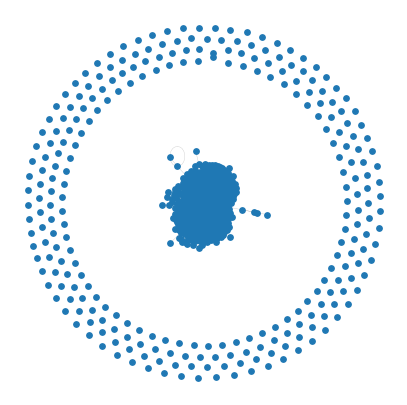

In [13]:
nodes_political_blogs_df2 = nodes_political_blogs_clean.copy()
nodes_political_blogs_df2['pos2d'] = nodes_political_blogs_df2[' _pos'].apply(parse_pos)

valid_nodes = set(nodes_political_blogs_df2['# index'])

edges_political_blogs_df2 = edges_political_blogs_df[
    edges_political_blogs_df['# source'].isin(valid_nodes) &
    edges_political_blogs_df[' target'].isin(valid_nodes)
]

import networkx as nx

G_political_blogs = nx.Graph()

# Node
for _, row in nodes_political_blogs_df2.iterrows():
    G_political_blogs.add_node(row['# index'], pos=row['pos2d'])

# Edge
G_political_blogs.add_edges_from(zip(edges_political_blogs_df2['# source'], edges_political_blogs_df2[' target']))

import matplotlib.pyplot as plt

pos = nx.get_node_attributes(G_political_blogs, 'pos')

plt.figure(figsize=(5, 5))
nx.draw_networkx_nodes(G_political_blogs, pos, node_size=15)
nx.draw_networkx_edges(G_political_blogs, pos, alpha=0.2, width=0.3)
plt.axis('off')
plt.show()

In [14]:
isolated_nodes = list(nx.isolates(G_political_blogs))

print("Number of isolated nodes:", len(isolated_nodes))
print("Isolated nodes:", isolated_nodes)

Number of isolated nodes: 266
Isolated nodes: [2, 3, 24, 47, 48, 49, 53, 56, 59, 60, 62, 70, 73, 90, 93, 107, 110, 111, 119, 121, 125, 130, 133, 134, 138, 145, 147, 152, 160, 163, 168, 173, 175, 182, 194, 195, 196, 198, 205, 213, 220, 225, 227, 230, 231, 233, 235, 239, 241, 246, 250, 253, 257, 259, 260, 262, 264, 265, 269, 270, 284, 285, 293, 301, 303, 305, 318, 319, 321, 323, 329, 333, 335, 338, 341, 342, 345, 347, 358, 365, 368, 371, 374, 375, 385, 394, 397, 411, 412, 422, 424, 429, 432, 434, 446, 454, 455, 456, 457, 458, 462, 463, 472, 475, 477, 481, 484, 485, 509, 519, 521, 525, 527, 528, 530, 532, 544, 545, 551, 556, 557, 564, 568, 570, 575, 580, 581, 585, 591, 592, 593, 598, 605, 606, 607, 610, 626, 628, 629, 632, 635, 637, 638, 655, 657, 662, 664, 671, 672, 677, 691, 694, 696, 697, 705, 706, 709, 718, 722, 723, 727, 732, 733, 741, 745, 747, 749, 750, 751, 752, 758, 768, 769, 782, 784, 788, 794, 831, 843, 844, 852, 865, 866, 876, 901, 904, 905, 916, 922, 923, 927, 947, 956, 968, 

In [15]:
# 1. isolated nodes
isolated_nodes = list(nx.isolates(G_political_blogs))

# 2. Removing isolated nodes and making node dataframe
nodes_political_blogs_clean_noiso = nodes_political_blogs_clean[
    ~nodes_political_blogs_clean['# index'].isin(isolated_nodes)
].copy()

# 3. encoding
cols = [' source']

for col in cols:
    nodes_political_blogs_clean_noiso[col + '_enc'] = (
        nodes_political_blogs_clean_noiso[col].astype('category').cat.codes
    )

nodes_political_blogs_clean_noiso.head()

,# index,label,source,value,_pos,source_enc
0,0,100monkeystyping.com,Blogarama,0,"array([ 19.03671634, -10.42473 ])",12
1,1,12thharmonic.com/wordpress,BlogCatalog,0,"array([ 18.10776658, -11.24572572])",0
4,4,750volts.blogspot.com,Blogarama,0,"array([12.55226328, -4.49266626])",12
5,5,95theses.blogspot.com,Blogarama,0,"array([ 27.34851662, -14.05935072])",12
6,6,abbadabbaduo.blogspot.com,"Blogarama,LeftyDirectory",0,"array([ 14.2559397 , -17.11646864])",22


In [16]:
print("Original nodes:", nodes_political_blogs_clean.shape[0])
print("Isolated nodes:", len(isolated_nodes))
print("After removing isolated nodes:", nodes_political_blogs_clean_noiso.shape[0])

Original nodes: 1490
Isolated nodes: 266
After removing isolated nodes: 1224


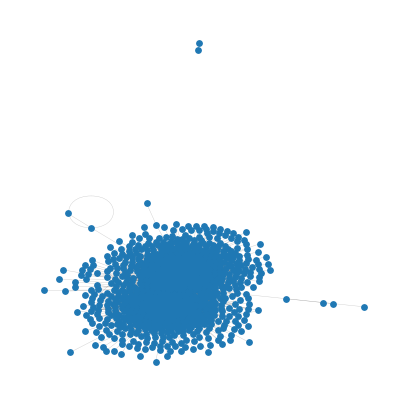

In [17]:
nodes_political_blogs_df2 = nodes_political_blogs_clean_noiso.copy()
nodes_political_blogs_df2['pos2d'] = nodes_political_blogs_df2[' _pos'].apply(parse_pos)

valid_nodes = set(nodes_political_blogs_df2['# index'])

edges_political_blogs_df2 = edges_political_blogs_df[
    edges_political_blogs_df['# source'].isin(valid_nodes) &
    edges_political_blogs_df[' target'].isin(valid_nodes)
]

import networkx as nx

# undirected
G_political_blogs = nx.Graph()

# directed
# G_political_blogs = nx.DiGraph()

# Node
for _, row in nodes_political_blogs_df2.iterrows():
    G_political_blogs.add_node(row['# index'], pos=row['pos2d'])

# Edge
G_political_blogs.add_edges_from(zip(edges_political_blogs_df2['# source'], edges_political_blogs_df2[' target']))

import matplotlib.pyplot as plt

pos = nx.get_node_attributes(G_political_blogs, 'pos')

plt.figure(figsize=(5, 5))
nx.draw_networkx_nodes(G_political_blogs, pos, node_size=15)
nx.draw_networkx_edges(G_political_blogs, pos, alpha=0.2, width=0.3)
plt.axis('off')
plt.show()

In [18]:
print("The number of nodes: {}".format(len(G_political_blogs.nodes)))
print("Number of edges: {}".format(G_political_blogs.number_of_edges()))
print("Density of the graph: {}".format(np.round(nx.density(G_political_blogs), 4)))

The number of nodes: 1224
Number of edges: 16718
Density of the graph: 0.0223


In [19]:
A = nx.to_numpy_array(G_political_blogs)
print(A)

[[0. 1. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [20]:
np.allclose(A, A.T)

True

In [21]:
nodes_political_blogs_clean_noiso.head()

,# index,label,source,value,_pos,source_enc
0,0,100monkeystyping.com,Blogarama,0,"array([ 19.03671634, -10.42473 ])",12
1,1,12thharmonic.com/wordpress,BlogCatalog,0,"array([ 18.10776658, -11.24572572])",0
4,4,750volts.blogspot.com,Blogarama,0,"array([12.55226328, -4.49266626])",12
5,5,95theses.blogspot.com,Blogarama,0,"array([ 27.34851662, -14.05935072])",12
6,6,abbadabbaduo.blogspot.com,"Blogarama,LeftyDirectory",0,"array([ 14.2559397 , -17.11646864])",22


In [22]:
print(nodes_political_blogs_clean_noiso[' value'].value_counts())
print("")
print(nodes_political_blogs_clean_noiso[' source_enc'].value_counts())

 value
1    636
0    588
Name: count, dtype: int64

 source_enc
12    466
0     132
45    124
33    120
32     67
13     48
35     44
30     36
22     36
3      31
43     16
40     10
7       8
2       7
10      6
15      6
4       5
23      5
39      5
21      5
34      4
29      4
20      4
14      4
25      3
46      3
17      2
31      2
9       2
41      2
28      1
19      1
18      1
6       1
11      1
8       1
16      1
5       1
36      1
38      1
27      1
24      1
44      1
37      1
42      1
26      1
1       1
Name: count, dtype: int64


In [23]:
print(nodes_political_blogs_clean_noiso[' source'].value_counts())

 source
Blogarama                                                         466
BlogCatalog                                                       132
eTalkingHead                                                      124
LabeledManually                                                   120
CampaignLine                                                       67
Blogarama,BlogCatalog                                              48
LeftyDirectory                                                     44
Blogarama,eTalkingHead                                             36
Blogarama,LeftyDirectory                                           36
BlogPulse                                                          31
LeftyDirectory,eTalkingHead                                        16
LeftyDirectory,LabeledManually                                     10
BlogPulse,LeftyDirectory                                            8
BlogCatalog,eTalkingHead                                            7
BlogPulse,eT

In [24]:
source_counts = nodes_political_blogs_clean_noiso[' source_enc'].value_counts()

small_source = source_counts[source_counts < 100].index

nodes_political_blogs_clean_noiso[' source_grouped'] = nodes_political_blogs_clean_noiso[' source_enc'].replace(
    small_source, '1'
)

nodes_political_blogs_clean_noiso[' source_grouped'].value_counts()

 source_grouped
12    466
1     382
0     132
45    124
33    120
Name: count, dtype: int64

In [25]:
nodes_political_blogs_clean_noiso.head()

,# index,label,source,value,_pos,source_enc,source_grouped
0,0,100monkeystyping.com,Blogarama,0,"array([ 19.03671634, -10.42473 ])",12,12
1,1,12thharmonic.com/wordpress,BlogCatalog,0,"array([ 18.10776658, -11.24572572])",0,0
4,4,750volts.blogspot.com,Blogarama,0,"array([12.55226328, -4.49266626])",12,12
5,5,95theses.blogspot.com,Blogarama,0,"array([ 27.34851662, -14.05935072])",12,12
6,6,abbadabbaduo.blogspot.com,"Blogarama,LeftyDirectory",0,"array([ 14.2559397 , -17.11646864])",22,1


In [26]:
liberal_blogs = [
    "dailykos.com",
    "talkingpointsmemo.com",
    "atrios.blogspot.com",
    "washingtonmonthly.com",
    "wonkette.com",
    "juancole.com",
    "yglesias.typepad.com",
    "crookedtimber.org",
    "mydd.com",
    "oliverwillis.com",
    "blog.johnkerry.com",
    "pandagon.net",
    "talkleft.com",
    "digbysblog.blogspot.com",
    "politicalwire.com",
    "j-bradford-delong.net",
    "prospect.org/weblog",
    "americablog.blogspot.com",
    "theleftcoaster.com",
    "jameswolcott.com"
]

conservative_blogs = [
    "powerlineblog.com",
    "instapundit.com",
    "littlegreenfootballs.com",
    "hughhewitt.com",
    "andrewsullivan.com",
    "captainsquartersblog.com",
    "wizbangblog.com",
    "indcjournal.com",
    "michellemalkin.com",
    "blogsforbush.com",
    "allahpundit.com",
    "belmontclub.blogspot.com",
    "realclearpolitics.com",
    "volokh.com",
    "timblair.spleenville.com",
    "windsofchange.net",
    "vodkapundit.com",
    "rogerlsimon.com",
    "deanesmay.com",
    "mypetjawa.mu.nu"
]

In [27]:
print(nodes_political_blogs_clean_noiso[' label'].value_counts())

 label
100monkeystyping.com                1
happyhomeschooler.blog-city.com     1
henerd.com                          1
hectorvex.blogspot.com              1
heavylifting.blogspot.com           1
                                   ..
polizeros.com                       1
politicswithrichard.blogspot.com    1
politics.feedster.com               1
politicalwire.com                   1
zeph1z.tripod.com/blog              1
Name: count, Length: 1224, dtype: int64


In [28]:
labels = nodes_political_blogs_clean_noiso[' label'].astype(str).str.strip().str.lower()

liberal_found = [b for b in liberal_blogs if b in labels.values]
liberal_missing = [b for b in liberal_blogs if b not in labels.values]

conservative_found = [b for b in conservative_blogs if b in labels.values]
conservative_missing = [b for b in conservative_blogs if b not in labels.values]

print("Liberal found:", len(liberal_found), liberal_found)
print("Liberal missing:", len(liberal_missing), liberal_missing)

print("Conservative found:", len(conservative_found), conservative_found)
print("Conservative missing:", len(conservative_missing), conservative_missing)

Liberal found: 18 ['dailykos.com', 'talkingpointsmemo.com', 'atrios.blogspot.com', 'washingtonmonthly.com', 'wonkette.com', 'juancole.com', 'crookedtimber.org', 'mydd.com', 'oliverwillis.com', 'blog.johnkerry.com', 'pandagon.net', 'talkleft.com', 'digbysblog.blogspot.com', 'politicalwire.com', 'prospect.org/weblog', 'americablog.blogspot.com', 'theleftcoaster.com', 'jameswolcott.com']
Liberal missing: 2 ['yglesias.typepad.com', 'j-bradford-delong.net']
Conservative found: 18 ['powerlineblog.com', 'instapundit.com', 'hughhewitt.com', 'andrewsullivan.com', 'wizbangblog.com', 'indcjournal.com', 'michellemalkin.com', 'blogsforbush.com', 'allahpundit.com', 'belmontclub.blogspot.com', 'realclearpolitics.com', 'volokh.com', 'timblair.spleenville.com', 'windsofchange.net', 'vodkapundit.com', 'rogerlsimon.com', 'deanesmay.com', 'mypetjawa.mu.nu']
Conservative missing: 2 ['littlegreenfootballs.com', 'captainsquartersblog.com']


In [29]:
df = nodes_political_blogs_clean_noiso.copy()

label_clean = df[' label'].astype(str).str.strip().str.lower()

liberal_set = set([b.lower() for b in liberal_blogs])
conservative_set = set([b.lower() for b in conservative_blogs])

df['party'] = 2
df.loc[label_clean.isin(liberal_set), 'party'] = 0
df.loc[label_clean.isin(conservative_set), 'party'] = 1

In [30]:
df[' source_grouped'].value_counts()

 source_grouped
12    466
1     382
0     132
45    124
33    120
Name: count, dtype: int64

In [31]:
cov_cols = [' value', ' source_grouped']

df = nodes_political_blogs_clean_noiso.copy()

for col in cov_cols:
    df[col + '_enc'] = df[col].astype('category').cat.codes

X = df[[col + '_enc' for col in cov_cols]].to_numpy()
Z_tilde = make_Z_tilde(X)

K = 2
n_z = len(np.unique(Z_tilde))

B_init, density = make_initial_B_from_density(A, K=K, structure="weak_assortative")


model = models.MultiCovariateModel(
    B=B_init,
    covariates=[
        models.Covariate.simple(0.0, 2),
        models.Covariate.simple(0.0, 5)
    ],
    link=models.LinkFunction.identity()
)


net = generation.GeneratedNetwork(
    A=sparse.csr_matrix(A),
    theta=np.zeros(A.shape[0], dtype=int),
    Z=X,
    Z_tilde=Z_tilde,
    block_sizes=np.ones(K * n_z, dtype=int),
    model=model
)

In [32]:
B_init, density = make_initial_B_from_density(A, K=K, structure="weak_assortative")

B_init

array([[0.02903426, 0.01563383],
       [0.01563383, 0.02903426]])

In [33]:
import numpy as np
import pandas as pd

def estimate_probability_matrix(A, labels, directed=False):
    labels = np.asarray(labels)
    groups = np.sort(np.unique(labels))
    K = len(groups)

    B_hat = np.zeros((K, K))

    for i, g1 in enumerate(groups):
        idx1 = np.where(labels == g1)[0]

        for j, g2 in enumerate(groups):
            idx2 = np.where(labels == g2)[0]

            A_sub = A[np.ix_(idx1, idx2)]

            if g1 == g2:
                if directed:
                    denom = len(idx1) * (len(idx1) - 1)
                    num = A_sub.sum() - np.trace(A_sub)
                else:
                    denom = len(idx1) * (len(idx1) - 1)
                    num = A_sub.sum() - np.trace(A_sub)
            else:
                denom = len(idx1) * len(idx2)
                num = A_sub.sum()

            B_hat[i, j] = num / denom if denom > 0 else 0

    return B_hat

In [34]:
from sklearn.cluster import SpectralClustering

sc = SpectralClustering(n_clusters=K, affinity='precomputed', assign_labels='kmeans', random_state=0)
sc_labels = sc.fit_predict(A)
B_init = estimate_probability_matrix(A, sc_labels, directed=True)

B_init

array([[0.02240389, 0.        ],
       [0.        , 1.        ]])

In [35]:
value_labels = df[' value_enc'].to_numpy()

B_init = estimate_probability_matrix(A, value_labels, directed=False)
# B_init = np.clip(B_init, 1e-6, 1 - 1e-6)

print(B_init)

[[0.04230551 0.00421159]
 [0.00421159 0.03882038]]


In [36]:
ic = estimation.initial_cluster(
    net, k=K, d=len(net.block_sizes), random_state=0)

rc = estimation.reconcile_clusters(net, ic)

df['ACSBM_initial'] = ic.theta_tilde
df['ACSBM_cluster'] = rc.theta

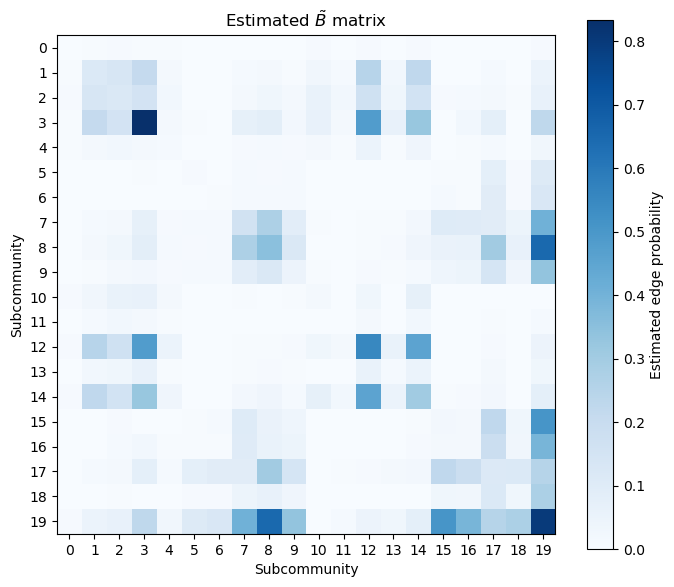

In [37]:
Bhat_tilde, groups = estimate_block_matrix(A, df['ACSBM_initial'])

plt.figure(figsize=(7, 6))
plt.imshow(Bhat_tilde, cmap='Blues')
plt.colorbar(label='Estimated edge probability')
plt.xticks(range(len(groups)), groups)
plt.yticks(range(len(groups)), groups)
plt.xlabel('Subcommunity')
plt.ylabel('Subcommunity')
plt.title(r'Estimated $\tilde{B}$ matrix')
plt.tight_layout()
plt.show()

In [38]:
# ACSBM_AA step1/step3
net_aa = generation.GeneratedNetwork(
    A=A,
    theta=net.theta,
    Z=net.Z,
    Z_tilde=net.Z_tilde,
    block_sizes=net.block_sizes,
    model=net.model
)

# Step1 on AA
ic_aa = estimation.initial_cluster_DA(net_aa, k=model.n_communities, d=len(net_aa.block_sizes), random_state=0)

# Step3 on AA
rc_aa = estimation.reconcile_clusters(net_aa, ic_aa)

df['DASE_initial'] = ic_aa.theta_tilde
df['DASE_cluster'] = rc_aa.theta

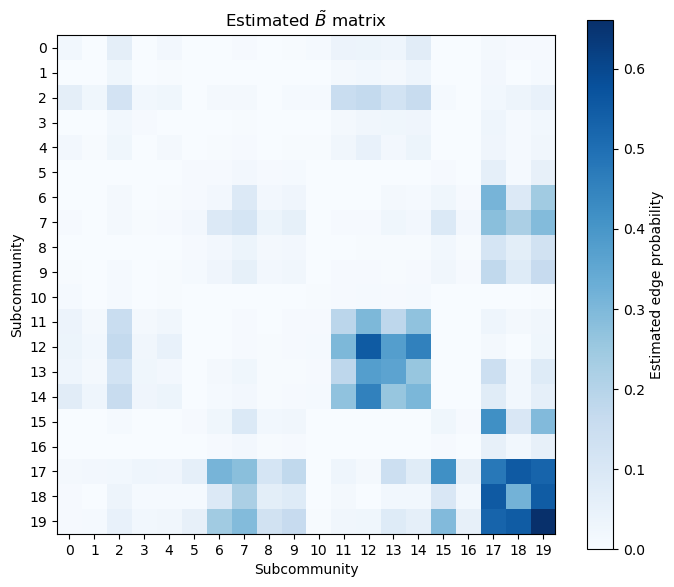

In [39]:
Bhat_tilde, groups = estimate_block_matrix(A, df['DASE_initial'])

plt.figure(figsize=(7, 6))
plt.imshow(Bhat_tilde, cmap='Blues')
plt.colorbar(label='Estimated edge probability')
plt.xticks(range(len(groups)), groups)
plt.yticks(range(len(groups)), groups)
plt.xlabel('Subcommunity')
plt.ylabel('Subcommunity')
plt.title(r'Estimated $\tilde{B}$ matrix')
plt.tight_layout()
plt.show()

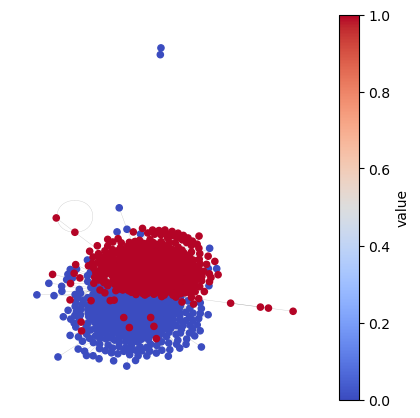

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# node id -> value mapping
value_map = dict(zip(nodes_political_blogs_df2['# index'], nodes_political_blogs_df2[' value']))

# Bring the value based on the graph node order
node_values = [value_map[node] for node in G_political_blogs.nodes()]

plt.figure(figsize=(5, 5))

nx.draw_networkx_edges(
    G_political_blogs, pos,
    alpha=0.2, width=0.3
)

nodes = nx.draw_networkx_nodes(
    G_political_blogs, pos,
    node_size=20,
    node_color=node_values,
    cmap='coolwarm'
)

plt.colorbar(nodes, label='value')
plt.axis('off')
plt.show()

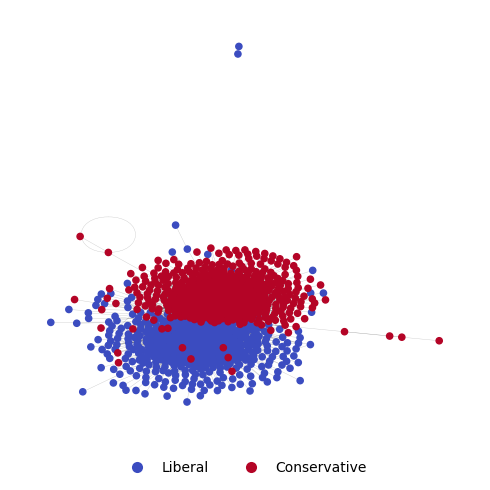

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D
from matplotlib import cm
from matplotlib.colors import Normalize

# node id -> value mapping
value_map = dict(zip(nodes_political_blogs_df2['# index'], nodes_political_blogs_df2[' value']))

# bring the value based on the graph node order
node_values = [value_map[node] for node in G_political_blogs.nodes()]

fig, ax = plt.subplots(figsize=(5, 5))

nx.draw_networkx_edges(G_political_blogs, pos, alpha=0.2, width=0.3, ax=ax)

nx.draw_networkx_nodes(G_political_blogs, pos, node_size=20, node_color=node_values, cmap='coolwarm', vmin=0, vmax=1, ax=ax)

cmap = cm.get_cmap('coolwarm')
norm = Normalize(vmin=0, vmax=1)

legend_elements = [
    Line2D([0], [0], marker='o', color='none', label='Liberal', markerfacecolor=cmap(norm(0)), markeredgecolor='none', markersize=8),
    Line2D([0], [0], marker='o', color='none', label='Conservative', markerfacecolor=cmap(norm(1)), markeredgecolor='none', markersize=8)
]

ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=False)

ax.axis('off')
plt.tight_layout()
plt.show()

In [42]:
import numpy as np
import pandas as pd

def make_subcommunity_annotation(df, sub_col, group_col, value_col, source_col):
    sub_info = (
        df.groupby(sub_col)
        .agg(
            group=(group_col, lambda x: x.mode().iloc[0]),
            value=(value_col, lambda x: x.mode().iloc[0]),
            source=(source_col, lambda x: x.mode().iloc[0]),
            n=(sub_col, "size")
        )
        .reset_index()
        .rename(columns={sub_col: "subcommunity"})
    )

    sub_info = sub_info.sort_values(["group", "value", "source"]).reset_index(drop=True)

    return sub_info

In [43]:
import matplotlib.pyplot as plt
import numpy as np

def plot_btilde_with_covariates(B, sub_info, title=r"Estimated $\tilde{B}$ matrix"):
    m = B.shape[0]

    fig, ax = plt.subplots(figsize=(8, 7))

    im = ax.imshow(B, cmap='viridis', aspect='equal', vmin=0, vmax=1)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Estimated edge probability')
    cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])

    ax.set_xticks(np.arange(m))
    ax.set_yticks(np.arange(m))
    ax.set_xticklabels([""] * m)
    ax.set_yticklabels([""] * m)

    ax.set_xticks(np.arange(-0.5, m, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, m, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.3)
    ax.tick_params(which="minor", bottom=False, left=False)

    # group boundary line
    group_arr = sub_info["group"].to_numpy()
    boundaries = np.where(group_arr[:-1] != group_arr[1:])[0] + 0.5

    for b in boundaries:
        ax.axvline(b, color="black", linewidth=1.5)
        ax.axhline(b, color="black", linewidth=1.5)

    # top annotation positions
    y_group = -2.0
    y_value = -1.35
    y_source = -0.75

    ax.text(-1.4, y_group, "group:", ha="right", va="center", fontsize=11)
    ax.text(-1.4, y_value, "value:", ha="right", va="center", fontsize=11)
    ax.text(-1.4, y_source, "source:", ha="right", va="center", fontsize=11)

    # group labels with horizontal line
    for g in np.unique(group_arr):
        idx = np.where(group_arr == g)[0]
        center = idx.mean()

        ax.text(center, y_group, str(int(g) + 1), ha="center", va="center", fontsize=11)
        ax.plot(
            [idx.min() - 0.4, idx.max() + 0.4],
            [y_group + 0.25, y_group + 0.25],
            color="gray",
            linewidth=1
        )

    # value labels
    value_arr = sub_info["value"].astype(str).to_numpy()
    source_arr = sub_info["source"].astype(str).to_numpy()

    for j in range(m):
        ax.text(j, y_value, value_arr[j], ha="center", va="center", fontsize=9)
        ax.text(j, y_source, source_arr[j], ha="center", va="center", fontsize=8, rotation=90)

    ax.set_title(title, pad=55)
    ax.set_xlabel("Subcommunity")
    ax.set_ylabel("Subcommunity")

    plt.tight_layout()
    plt.show()

In [44]:
import matplotlib.pyplot as plt
import numpy as np

def plot_btilde_with_covariates(B, sub_info, title=r"Estimated $\tilde{B}$ matrix"):
# def plot_btilde_with_covariates(B, sub_info):
    m = B.shape[0]

    fig, ax = plt.subplots(figsize=(8, 7))

    im = ax.imshow(B, cmap='viridis', aspect='equal', vmin=0, vmax=1)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Estimated edge probability')
    cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])

    ax.set_xticks(np.arange(m))
    ax.set_yticks(np.arange(m))
    ax.set_xticklabels([""] * m)
    ax.set_yticklabels([""] * m)

    ax.set_xticks(np.arange(-0.5, m, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, m, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.3)
    ax.tick_params(which="minor", bottom=False, left=False)

    # group boundary line
    group_arr = sub_info["group"].to_numpy()
    boundaries = np.where(group_arr[:-1] != group_arr[1:])[0] + 0.5

    for b in boundaries:
        ax.axvline(b, color="black", linewidth=1.5)
        ax.axhline(b, color="black", linewidth=1.5)

    # annotation y positions
    y_group = -2.3
    y_value = -1.45
    y_source = -0.75

    ax.text(-1.4, y_group, "group:", ha="right", va="center", fontsize=11)
    ax.text(-1.4, y_value, "value:", ha="right", va="center", fontsize=11)
    ax.text(-1.4, y_source, "source:", ha="right", va="center", fontsize=11)

    # group labels with horizontal line
    for g in np.unique(group_arr):
        idx = np.where(group_arr == g)[0]
        center = idx.mean()

        ax.text(center, y_group, str(int(g) + 1), ha="center", va="center", fontsize=11)
        ax.plot(
            [idx.min() - 0.4, idx.max() + 0.4],
            [y_group + 0.25, y_group + 0.25],
            color="gray",
            linewidth=1
        )

    # value labels: 0 -> Liberal, 1 -> Conservative
    value_arr = sub_info["value"].to_numpy()

    value_name = {
        0: "Liberal",
        1: "Conservative",
        "0": "Liberal",
        "1": "Conservative"
    }

    # source labels: 0~4 -> A~E
    source_arr_raw = sub_info["source"].to_numpy()

    source_name = {
        0: "A", 12: "B", 33: "C", 45: "D", 1: "E",
        "0": "A", "12": "B", "33": "C", "45": "D", "1": "E"
    }

    source_arr = np.array([source_name.get(x, str(x)) for x in source_arr_raw])

    # group 안에서 value별로 묶어서 한 번만 표시
    for g in np.unique(group_arr):
        idx_g = np.where(group_arr == g)[0]
        values_in_group = value_arr[idx_g]

        for v in np.unique(values_in_group):
            idx = idx_g[values_in_group == v]
            center = idx.mean()

            label = value_name.get(v, str(v))

            ax.text(center, y_value, label, ha="center", va="center", fontsize=9)

            ax.plot(
                [idx.min() - 0.4, idx.max() + 0.4],
                [y_value + 0.22, y_value + 0.22],
                color="gray",
                linewidth=0.8
            )

    for j in range(m):
        ax.text(j, y_source, source_arr[j], ha="center", va="center", fontsize=8)

    # ax.set_title(title, pad=65)
    ax.set_xlabel("Subcommunity")
    ax.set_ylabel("Subcommunity")

    plt.tight_layout()
    plt.show()

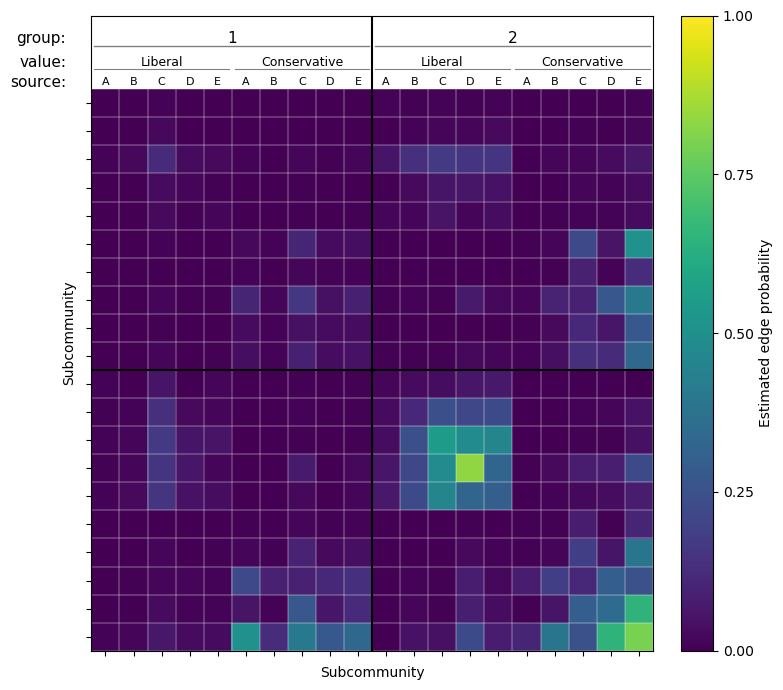

In [45]:
# 1. Compute Bhat_tilde
Bhat_tilde, groups = estimate_block_matrix(A, df['ACSBM_initial'])

# 2. Make the subcommunity annotation
sub_info = make_subcommunity_annotation(
    df,
    sub_col='ACSBM_initial',
    group_col='ACSBM_cluster',
    value_col=' value',
    source_col=' source_grouped'
)

# 3. Bhat_tilde re-ordering
groups = np.asarray(groups)
ordered_subs = sub_info['subcommunity'].to_numpy()
order_idx = [np.where(groups == s)[0][0] for s in ordered_subs]

Bhat_tilde_ordered = Bhat_tilde[np.ix_(order_idx, order_idx)]

plot_btilde_with_covariates(
    Bhat_tilde_ordered,
    sub_info
)

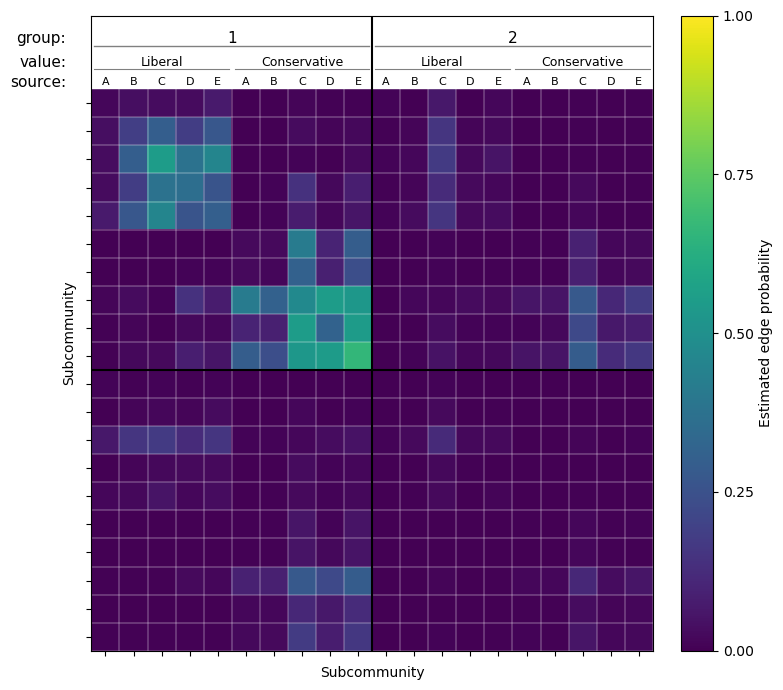

In [46]:
Bhat_tilde, groups = estimate_block_matrix(A, df['DASE_initial'])


# 2. Make the subcommunity annotation
sub_info = make_subcommunity_annotation(
    df,
    sub_col='DASE_initial',
    group_col='DASE_cluster',
    value_col=' value',
    source_col=' source_grouped'
)

# 3. Bhat_tilde re-ordering
groups = np.asarray(groups)
ordered_subs = sub_info['subcommunity'].to_numpy()
order_idx = [np.where(groups == s)[0][0] for s in ordered_subs]

Bhat_tilde_ordered = Bhat_tilde[np.ix_(order_idx, order_idx)]

plot_btilde_with_covariates(
    Bhat_tilde_ordered,
    sub_info
)

In [47]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

def estimate_beta_pairwise_logistic(A, theta_hat, covariates):
    A = np.asarray(A)
    theta_hat = np.asarray(theta_hat)

    n = A.shape[0]

    if A.shape != (n, n):
        raise ValueError("A must be square.")

    if len(theta_hat) != n:
        raise ValueError("theta_hat and A must have the same number of nodes.")

    covariates = {
        name: np.asarray(values)
        for name, values in covariates.items()
    }

    for name, values in covariates.items():
        if len(values) != n:
            raise ValueError(
                f"Covariate '{name}' has length {len(values)}, but n={n}."
            )

    communities = np.unique(theta_hat)
    rows = []

    for i in range(n):
        for j in range(i + 1, n):
            row = {"edge": int(A[i, j])}

            for a, k in enumerate(communities):
                for l in communities[a:]:
                    name = f"block_{k}_{l}"
                    row[name] = int(
                        (theta_hat[i] == k and theta_hat[j] == l)
                        or
                        (theta_hat[i] == l and theta_hat[j] == k)
                    )

            for cov_name, cov_values in covariates.items():
                row[f"same_{cov_name}"] = int(
                    cov_values[i] == cov_values[j]
                )

            rows.append(row)

    pair_df = pd.DataFrame(rows)

    y = pair_df["edge"].astype(float)
    X_design = pair_df.drop(columns="edge").astype(float)

    model = sm.Logit(y, X_design)
    result = model.fit()

    return result, pair_df

In [48]:
covariates = {
    "value": df[" value"].to_numpy(),
    "source": df[" source_grouped"].to_numpy()
}

result, df_pairwise = estimate_beta_pairwise_logistic(
    A=A,
    theta_hat=df["ACSBM_cluster"].to_numpy(),
    covariates=covariates
)

print(result.summary())
print(result.params)

Optimization terminated successfully.
         Current function value: 0.091857
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                   edge   No. Observations:               748476
Model:                          Logit   Df Residuals:                   748471
Method:                           MLE   Df Model:                            4
Date:                Thu, 27 Aug 2026   Pseudo R-squ.:                  0.1414
Time:                        17:15:27   Log-Likelihood:                -68753.
converged:                       True   LL-Null:                       -80073.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
block_0_0      -6.2698      0.029   -212.726      0.000      -6.328      -6.212
block_0_1      -5.4877   

In [55]:
print("value: {}".format(np.exp(2.328)))
print("value: {}".format(np.exp(0.026)))

value: 10.257406192163353
value: 1.026340948473442


In [56]:
log_odds = np.array([[-6.270, -5.488], [-5.488, -4.117]]) + np.array([[2.328, 0], [0, 2.328]]) + np.array([[0.026, 0], [0, 0.026]])
prob_matrix = 1 / (1 + np.exp(-log_odds))

print(np.round(prob_matrix, 4))

[[0.0195 0.0041]
 [0.0041 0.1464]]


In [51]:
covariates = {
    "value": df[" value"].to_numpy(),
    "source": df[" source_grouped"].to_numpy()
}

result, df_pairwise = estimate_beta_pairwise_logistic(
    A=A,
    theta_hat=df["DASE_cluster"].to_numpy(),
    covariates=covariates
)

print(result.summary())
print(result.params)

Optimization terminated successfully.
         Current function value: 0.086283
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                   edge   No. Observations:               748476
Model:                          Logit   Df Residuals:                   748471
Method:                           MLE   Df Model:                            4
Date:                Thu, 27 Aug 2026   Pseudo R-squ.:                  0.1935
Time:                        17:15:39   Log-Likelihood:                -64581.
converged:                       True   LL-Null:                       -80073.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
block_0_0      -3.7050      0.028   -134.663      0.000      -3.759      -3.651
block_0_1      -5.4646   

In [57]:
print("value: {}".format(np.exp(2.387)))
print("value: {}".format(np.exp(-0.138)))

value: 10.88080252286168
value: 0.8710986917457983


In [58]:
log_odds = np.array([[-3.705, -5.465], [-5.465, -6.719]]) + np.array([[2.387, 0], [0, 2.387]]) + np.array([[-0.138, 0], [0, -0.138]])
prob_matrix = 1 / (1 + np.exp(-log_odds))

print(np.round(prob_matrix, 4))

[[0.1891 0.0042]
 [0.0042 0.0113]]
